# 01 — Esplorazione Dataset MVTec AD
Questo notebook serve per capire i dati prima di iniziare a costruire il modello.

In [ ]:
# --- Setup paths ---
# Usa pathlib per calcolare il percorso assoluto alla root del progetto
# indipendentemente da dove VS Code ha lanciato il kernel.
import sys
from pathlib import Path

# Risali di una cartella rispetto a 'notebooks/' per trovare la project root
PROJECT_ROOT = Path().resolve().parent

# Aggiungi src/ al path Python così possiamo importare i nostri moduli
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# Percorso assoluto al dataset — non dipende più dalla working directory
DATASET_PATH = str(PROJECT_ROOT / 'data' / 'mvtec_ad')
CATEGORY = 'leather'

print(f'Project root : {PROJECT_ROOT}')
print(f'Dataset path : {DATASET_PATH}')
print(f'src in path  : {PROJECT_ROOT / "src"}')

# Verifica rapida che il dataset esista
category_path = PROJECT_ROOT / 'data' / 'mvtec_ad' / CATEGORY
if category_path.exists():
    print(f'\n✅ Dataset trovato: {category_path}')
else:
    print(f'\n❌ Dataset non trovato in: {category_path}')
    print('   Controlla che il download sia completo e la struttura sia data/mvtec_ad/')

Project root : C:\Users\sbert\OneDrive\Documenti\Claude\Projects\Computer Vision\Final_Project
Dataset path : C:\Users\sbert\OneDrive\Documenti\Claude\Projects\Computer Vision\Final_Project\data\mvtec_ad
src in path  : C:\Users\sbert\OneDrive\Documenti\Claude\Projects\Computer Vision\Final_Project\src

✅ Dataset trovato: C:\Users\sbert\OneDrive\Documenti\Claude\Projects\Computer Vision\Final_Project\data\mvtec_ad\metal_nut


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dataset import MVTecDataset

print('✅ Import completato')

✅ Import completato


In [3]:
# Carica il dataset
dataset = MVTecDataset(DATASET_PATH, category=CATEGORY, binary=True)
X_train, y_train = dataset.load_train()
X_test, y_test, class_names = dataset.load_test(return_classes=True)

print(f'Classi: {class_names}')
print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')

Training set — metal_nut: 220 immagini (tutte 'good')

Test set — metal_nut [binaria]:
  Classe 0 (good): 22 immagini
  Classe 1 (defective): 93 immagini
  Totale: 115 immagini

Classi: ['good']
Train shape: (220, 224, 224, 3)
Test shape:  (115, 224, 224, 3)


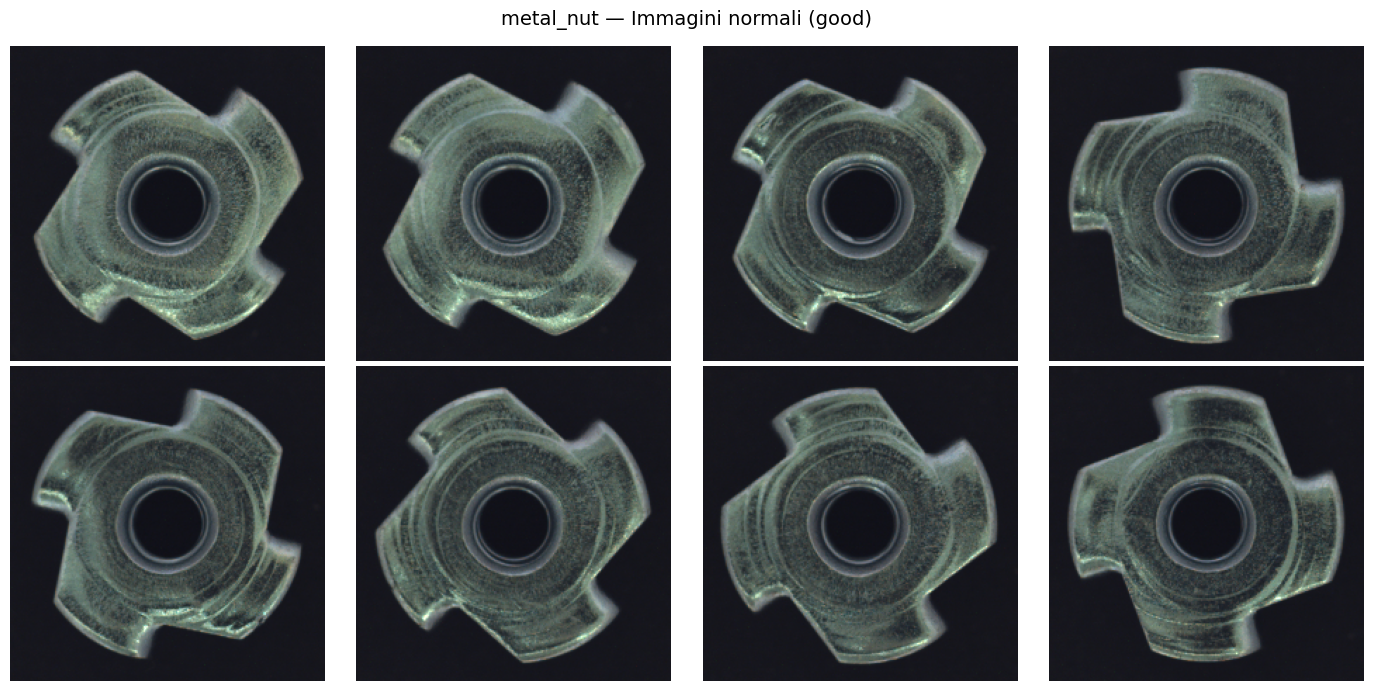

In [4]:
# Visualizza esempi di immagini normali (good)
good_imgs = X_train[:8]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle(f'{CATEGORY} — Immagini normali (good)', fontsize=14)
for ax, img in zip(axes.flatten(), good_imgs):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'outputs' / 'results' / f'{CATEGORY}_good_examples.png'), dpi=150)
plt.show()

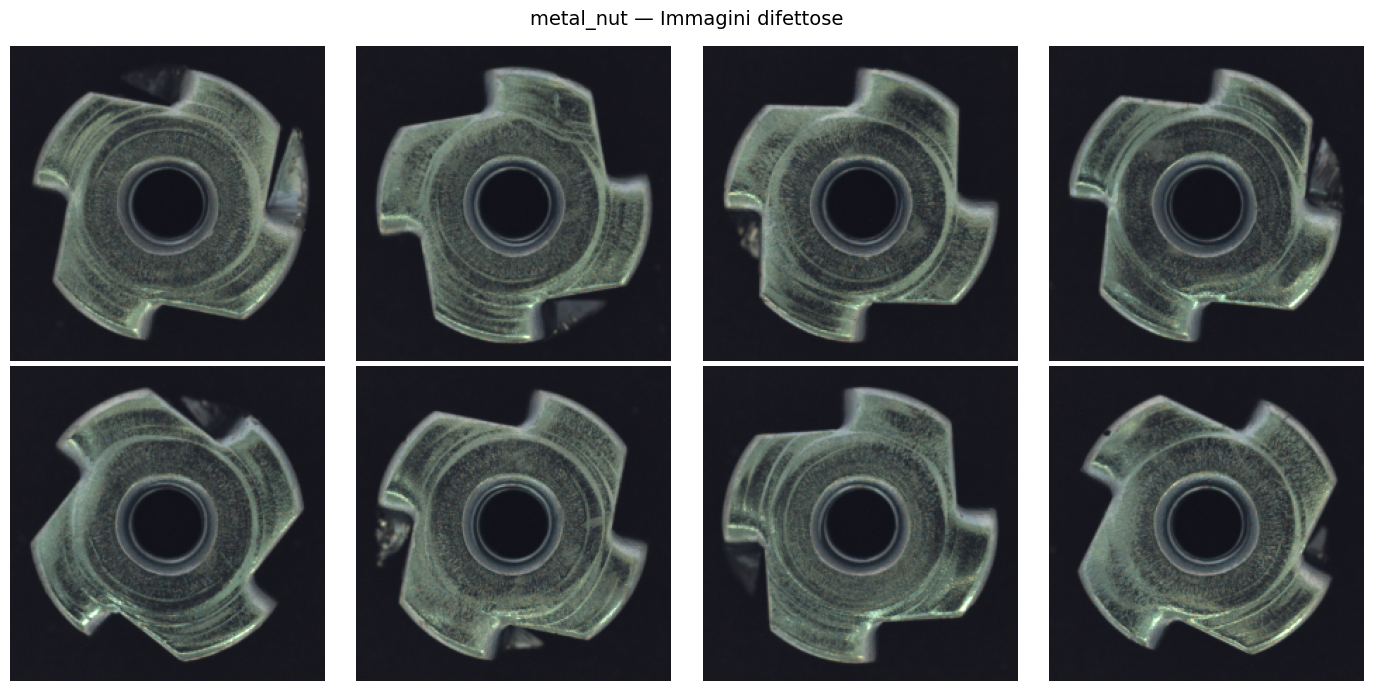

In [5]:
# Visualizza esempi di immagini difettose
defective_mask = y_test == 1
defective_imgs = X_test[defective_mask][:8]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle(f'{CATEGORY} — Immagini difettose', fontsize=14)
for ax, img in zip(axes.flatten(), defective_imgs):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'outputs' / 'results' / f'{CATEGORY}_defective_examples.png'), dpi=150)
plt.show()

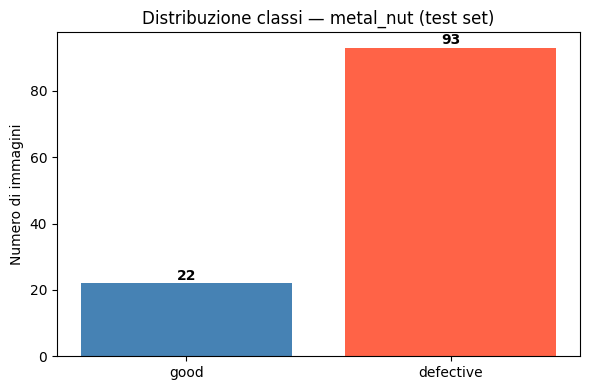

Bilanciamento: 22 good vs 93 defective
⚠️  Dataset sbilanciato — considera class_weight="balanced" nel modello


In [6]:
# Distribuzione delle classi nel test set
unique, counts = np.unique(y_test, return_counts=True)
labels = ['good', 'defective']

plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=['steelblue', 'tomato'])
plt.title(f'Distribuzione classi — {CATEGORY} (test set)')
plt.ylabel('Numero di immagini')
for i, c in enumerate(counts):
    plt.text(i, c + 1, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'outputs' / 'results' / f'{CATEGORY}_class_distribution.png'), dpi=150)
plt.show()

print(f'Bilanciamento: {counts[0]} good vs {counts[1]} defective')
if counts[0] != counts[1]:
    print('⚠️  Dataset sbilanciato — considera class_weight="balanced" nel modello')

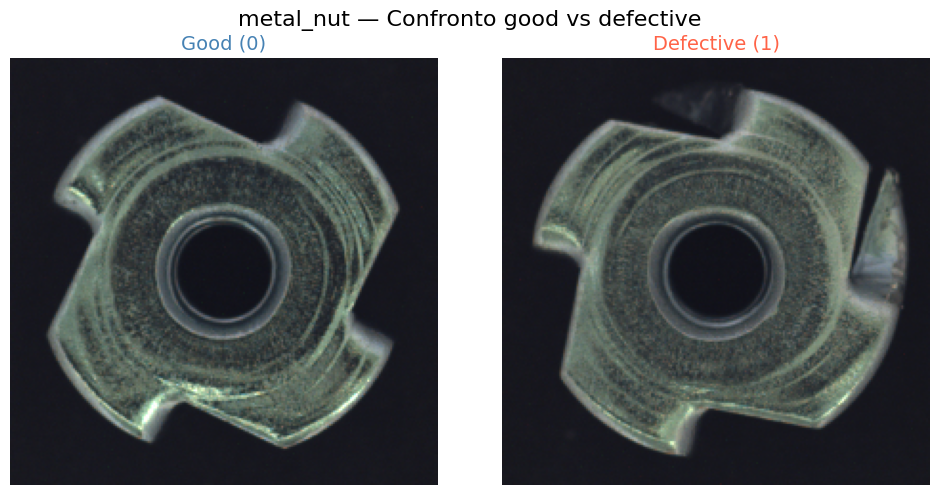

In [7]:
# Confronto affiancato good vs difettoso
good_example    = X_test[y_test == 0][0]
defect_example  = X_test[y_test == 1][0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(good_example)
ax1.set_title('Good (0)', fontsize=14, color='steelblue')
ax1.axis('off')
ax2.imshow(defect_example)
ax2.set_title('Defective (1)', fontsize=14, color='tomato')
ax2.axis('off')
plt.suptitle(f'{CATEGORY} — Confronto good vs defective', fontsize=16)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'outputs' / 'results' / f'{CATEGORY}_comparison.png'), dpi=150)
plt.show()